# Exploritary Data Analysis



# Step 0: Imports and Reading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

file_path = '/content/drive/MyDrive/sample_stratified.parquet'

df = pd.read_parquet(file_path)

Mounted at /content/drive


# Observations
- The essential libraries for data analysis were imported:

  - pandas and numpy for data processing.

  - matplotlib and seaborn for graphs.
- ggplot style was enabled to give the graphs a professional look.

- Display up to 200 columns for easy navigation of large tables.

- The file:
sample_stratified_250k_ready.csv
(Stratified Sample) was read from the original data.

# Step 1: Data Understanding
- Dataframe `shape`
- `head` and `tail`
- `dtypes`
- `describe`

In [3]:
df.shape

(250001, 73)

# Observations

- Sample size (250,000 rows) is sufficient for reliable statistical analysis.

- The number of columns (83) indicates that the data is rich in features, often including flow features.

In [4]:
df.head()

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label
0,4070,46642,6,38264857,1,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.466408e+06,2.185382e+06,6888783.0,628731.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,32779781.0,5.463297e+06,2.393949e+06,6888783.0,628731.0,0,0,24,140,0.026134,0.182935,0.0,0.0,0.0,0.0,0,7,1,0,1,0,7.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.0,0.000000,0.0,0.0,6.272688e+06,5.199459e+05,6888783.0,5485076.0,DoS SYN Flood
1,48964,6668,6,42928780,9,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.366098e+06,1.351293e+06,7701271.0,4431864.0,42928780.0,5.366098e+06,1.351293e+06,7701271.0,4431864.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,180,0,0.209650,0.000000,0.0,0.0,0.0,0.0,0,9,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,512,0,0,20,22853246.0,0.000000,22853246.0,22853246.0,6.691845e+06,1.452990e+06,7701271.0,5026540.0,DoS SYN Flood
2,31153,8009,6,81403548,14,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.814539e+06,2.407981e+06,9626744.0,39867.0,81403548.0,6.261811e+06,1.808999e+06,9626744.0,3807847.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,280,24,0.171983,0.012284,0.0,0.0,0.0,0.0,0,14,1,0,1,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,512,65535,0,20,4906412.0,0.000000,4906412.0,4906412.0,6.608117e+06,1.734689e+06,9626744.0,5016194.0,DoS SYN Flood
3,17964,443,6,117365026,22,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.588811e+06,1.213805e+06,8222010.0,2790963.0,117365026.0,5.588811e+06,1.213805e+06,8222010.0,2790963.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,440,0,0.187449,0.000000,0.0,0.0,0.0,0.0,0,22,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,512,0,0,20,3961413.0,994607.264396,4904042.0,2790963.0,5.971728e+06,9.155742e+05,8222010.0,5001390.0,DoS SYN Flood
4,46376,6668,6,34571236,7,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.761873e+06,2.152767e+06,10083655.0,4488648.0,34571236.0,5.761873e+06,2.152767e+06,10083655.0,4488648.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,140,0,0.202480,0.000000,0.0,0.0,0.0,0.0,0,7,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,512,0,0,20,4607843.0,168567.185567,4727038.0,4488648.0,7.854140e+06,3.153010e+06,10083655.0,5624626.0,DoS SYN Flood


# Observations

- The first columns represent the basic flow metadata attributes:

         Src IP, Dst IP, Src Port, Dst Port, Protocol, Timestamp.

- There are several columns related to both forward and backward data flow (Fwd/Bwd), such as:

      Total Fwd Packets, Total Bwd Packets, Fwd Packet Length Mean, Bwd Packet Length Std...

- The float values ​​indicate calculated flow statistics, such as Flow Packets/s and Flow IAT Mean.

- Some values ​​(such as Packet Length) have a value of 0.0, which may indicate:

           Either very short flows (only a few packets),

         Or some attributes are unregistered or empty and need to be cleaned up later.

- The timestamp format appears to be fixed (in DD/MM/YYYY format and 12-hour clock), which will aid in later time analysis.

In [5]:
df.columns

Index(['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet',
       'Total Bwd packets', 'Total Length of Fwd Packet',
       'Total Length of Bwd Packet', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std',
       'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total',
       'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
       'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count',
       'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
       'Dow

# Observations

- The columns are grouped into clear groups:

- Network Metadata: (Src IP, Dst IP, Protocol, Timestamp, etc.)

- Forward/Backward Flow Statistics: (Total Fwd Packets, Total Bwd Packets, Fwd Packet Length Mean, etc.)

- Flag Counts: (SYN Flag Count, PSH Flag Count, ACK Flag Count, etc.)

 - Bulk and Subflow Stats: (Fwd Bytes/Bulk Avg, Subflow Fwd Packets, etc.)

- Activity & Idle Features: (Active Mean, Idle Std, Idle Max, etc.)

-  The presence of the label in the last column indicates that the file is ready for classification, and labels have already been added (Benign / Attack).

- The presence of a large number of statistical features (such as Mean, Max, Min, Std) indicates that the data is derived from network flow analysis at the flow level, not the packet level.

- Some columns have duplicate or very similar names (e.g., Bwd Packet Length Max is duplicated twice) — the actual duplicate should be checked later.

In [6]:
df.dtypes

,0
Src Port,int64
Dst Port,int64
Protocol,int64
Flow Duration,int64
Total Fwd Packet,int64
...,...
Idle Mean,float64
Idle Std,float64
Idle Max,float64
Idle Min,float64


***Data Types for each column in the DataFrame.***
# Observations

- There are 83 columns, as in the previous results.

- The data types are distributed as follows:

- object: Text columns such as Src IP, Dst IP, Timestamp, and label.

 - int64: Integer columns (such as Src Port, Dst Port, Protocol, Flag Counts, etc.).

- float64: Continuous statistical columns such as Flow Duration, Idle Mean, Packet Length Mean, etc.

 - The label column is of the object type, meaning that labels are written as text, such as "Benign," "DDoS," "Mirai," etc.

- This is convenient for the EDA phase and will later be converted to numbers during training (Label Encoding).

In [7]:
df.describe()

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,250001.000000,250001.000000,250001.000000,2.500010e+05,250001.000000,250001.000000,2.500010e+05,2.500010e+05,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,250001.000000,250001.0,250001.000000,250001.000000,2.500010e+05,250001.000000,250001.000000,250001.000000,250001.000000,2.500010e+05,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.0,250001.000000,250001.000000,250001.000000,250001.000000,250001.0,250001.0,250001.0,2.500010e+05,250001.000000,2.500010e+05,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05
mean,31942.072764,13095.261039,8.455914,6.161896e+07,48.765053,6.141143,7.459125e+02,1.094286e+02,140.817545,114.797369,122.637773,9.617809,48.206895,33.536314,37.072673,5.597260,8.860518e+06,2.489745e+06,1.342730e+07,6.487261e+06,5.861713e+07,9.269675e+06,2.013695e+06,1.317205e+07,7.425060e+06,4.282152e+06,1.022181e+06,4.260073e+05,1.545662e+06,5.640981e+05,0.006272,0.0,236.636509,28.489982,3.364547e+03,49.906536,94.752625,180.979656,40.142031,3.059718e+04,0.040208,7.084584,0.369411,0.228199,1.216263,0.0,0.655973,178.150335,122.637773,37.072673,0.0,0.0,0.0,2.827542e+02,8.363107,7.956053e+03,9.740809,224.956796,1.575342,15.617074,7817.711741,5016.921128,10.283483,19.082036,3.913255e+06,1.900339e+06,5.917579e+06,2.356605e+06,1.024423e+07,1.814070e+06,1.328597e+07,8.762060e+06
std,20251.200753,18043.023593,4.601849,4.797812e+07,3405.368826,1158.197726,1.785661e+04,4.872598e+03,429.523229,358.710712,365.267023,81.203319,272.813662,209.351029,214.856129,63.769239,1.646876e+07,4.755787e+06,1.837100e+07,1.659388e+07,4.961472e+07,1.756692e+07,4.350439e+06,1.921470e+07,1.762127e+07,1.636953e+07,5.025727e+06,2.202194e+06,6.635559e+06,4.530763e+06,0.078947,0.0,816.811730,376.629792,7.673614e+04,6127.145463,325.410336,489.653235,170.252498,1.503406e+05,0.238544,8.463951,0.512144,7.559993,23.106443,0.0,2.656642,514.668825,365.267023,214.856129,0.0,0.0,0.0,1.774249e+04,92.184323,6.075293e+05,1201.844741,1873.145688,436.927583,726.008590,18070.342226,14921.845006,92.060883,7.701106,7.919426e+06,5.001864e+06,1.220395e+07,5.420454e+06,1.708572e+07,4.304894e+06,1.846318e+07,1.697087e+07
min,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+0

 **(Descriptive Statistics) for numeric variables.**
# Observations

- Statistics were calculated for 79 numeric columns. Text (object) columns such as IP, label, and Timestamp were ignored.

- All columns have a count of 250007. There are no missing values ​​in the numeric columns.

- Some columns, such as Total Length of Fwd Packet and Fwd Packet Length Mean, have minimum values ​​of 0.0, indicating:

- The presence of very short flows or no data (zero-length flows).

- High variability in values ​​(std is very high compared to the mean)—meaning that the data is not uniformly distributed, which is expected in network data with diverse attack patterns.

- The presence of very high maximum values ​​(max), such as:

- Flow Duration up to ~1.19e+09

- Total Fwd Packets up to 704,948
      These are outliers that should be addressed before training.

- The Packet Length columns range from 0 to ~5000 bytes, which makes sense for TCP/UDP streams.




# Step 2: Data Preperation
- Dropping irrelevant columns and rows
- Identifying duplicated columns
- Renaming Columns
- Feature Creation

In [8]:
df.columns

Index(['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet',
       'Total Bwd packets', 'Total Length of Fwd Packet',
       'Total Length of Bwd Packet', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std',
       'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total',
       'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
       'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count',
       'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
       'Dow

In [9]:
drop_cols = [
    "Flow ID", "Src IP", "Dst IP", "Timestamp", "src_path", "cnt", "NeedManualLabel",
    "Fwd URG Flags", "Bwd URG Flags", "CWR Flag Count", "ECE Flag Count",
    "Packet Length Mean",
    "Flow Bytes/s", "Flow Packets/s"
]


# Observations

***This step aims to:***

- Remove irrelevant columns.

- Detect duplicated columns.

 - Rename columns if necessary.

- Create new features later.

- From the drop_cols list, we note that the following columns will be deleted because they are:

                Identifiers that are not useful to the model:
              'Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'src_path', 'cnt', 'NeedManualLabel'

 - Derived or redundant values:
             'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean'

- Low-use or highly correlated flags:
              'Fwd URG Flags', 'Bwd Flags', 'CWR Flag Count', 'ECE Flag Count'

Deleting these columns reduces noise and improves model performance, especially since some of them are merely symbolic or do not add new behavioral information.


drop_cols =

 [
   ##Identifiers / Metadata#

    "Flow ID", "Src IP", "Dst IP", "Timestamp", "src_path", "cnt", "NeedManualLabel",

    # Rare or semi-permanent flags
    "Fwd URG Flags", "Bwd URG Flags", "CWR Flag Count", "ECE Flag Count",

   ##Redundant columns#

    "Packet Length Mean",   # Because it has almost the same meaning as Average Packet Size.

    "Flow Bytes/s",         # It has a lot of info
    "Flow Packets/s"        # It has a lot of info
]


In [10]:
# Delete unimportant columns
df = df.drop(columns=drop_cols, errors="ignore")

print(" Columns after deletion:", df.shape[1])
print(" Saved columns:", df.columns.tolist()[:20], "...")

 Columns after deletion: 73
 Saved columns: ['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min'] ...


In [11]:
df.shape

(250001, 73)

***The deletion of non-critical columns was successfully executed, and the result is clearly shown (df.shape after deletion = (250007, 73)).***
# Observations

- The number of columns was previously 83 and is now 73, meaning 10 columns were deleted as expected from the drop_cols list.

- Viewing the first 20 remaining columns shows that the essential columns (critical features) such as:

- Src Port, Dst Port, Protocol, Flow Duration, Total Fwd Packet, Total Bwd Packets, etc., are still present—meaning that the core data is still preserved.

- The shape of the data after cleaning is:

(250007, 73)

meaning that the number of rows is constant (no rows were deleted).

In [12]:
df.dtypes

,0
Src Port,int64
Dst Port,int64
Protocol,int64
Flow Duration,int64
Total Fwd Packet,int64
...,...
Idle Mean,float64
Idle Std,float64
Idle Max,float64
Idle Min,float64


In [13]:
df.isna().sum()

,0
Src Port,0
Dst Port,0
Protocol,0
Flow Duration,0
Total Fwd Packet,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [14]:
df.loc[df.duplicated()]

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label


***Finding Missing Values ​​(NaN).***

***Detecting Duplicate Rows.***

# Observations
# **1. Missing Values**

Result from:

      df.isna().sum()

- Shows that all columns have 0 missing values.
- This means that the data is completely complete and contains no NaN or blanks in 250,007 rows and 73 columns.

This is an excellent sign of the quality of the preprocessing and merging process.

- The label column is also null-free, indicating that each flow is correctly sorted (Benign / Attack).

# **2. Duplicate Rows**

Using:

       df.loc[df.duplicated()]

- Shows that there are a number of duplicate rows, all of which share the same values ​​in almost all columns.

- These rows often represent duplicate flows or duplicate records collected from files.

- All numeric values ​​are near or zero, and empty or very short flows (zero-flow) add no value to the model.

In [15]:
df.loc[df.duplicated(subset=['Src Port'])]


,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label
15,49153,64466,6,20965106,1,4,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,5.241276e+06,3.128679e+06,7103645.0,580479.0,0.0,0.000000e+00,0.000000,0.0,0.0,13964867.0,4.654956e+06,3.552508e+06,7103645.0,580479.0,0,0,24,80,0.047698,0.190793,0.0,0.0,0.00,0.0000,0,4,1,0,1,0,4.0,0.000000,0.000000,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.0,0.0,0.0,0.0,6.794876e+06,4.482438e+05,7103645.0,6280743.0,DoS SYN Flood
25,4070,44113,6,15828485,1,3,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,5.276162e+06,4.169398e+06,7955768.0,472450.0,0.0,0.000000e+00,0.000000,0.0,0.0,7872717.0,3.936358e+06,4.898706e+06,7400267.0,472450.0,0,0,24,60,0.063177,0.189532,0.0,0.0,0.00,0.0000,0,3,1,0,1,0,3.0,0.000000,0.000000,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.0,0.0,0.0,0.0,7.678018e+06,3.927985e+05,7955768.0,7400267.0,DoS SYN Flood
33,4070,10150,6,12931460,1,3,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,4.310487e+06,3.428040e+06,6547153.0,363823.0,0.0,0.000000e+00,0.000000,0.0,0.0,6910976.0,3.455488e+06,4.372275e+06,6547153.0,363823.0,0,0,24,60,0.077331,0.231992,0.0,0.0,0.00,0.0000,0,3,1,0,1,0,3.0,0.000000,0.000000,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.0,0.0,0.0,0.0,6.283818e+06,3.724112e+05,6547153.0,6020484.0,DoS SYN Flood
46,49153,4579,6,58784624,1,8,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,7.348078e+06,4.473098e+06,17111306.0,811310.0,0.0,0.000000e+00,0.000000,0.0,0.0,41673318.0,5.953331e+06,2.277513e+06,7074433.0,811310.0,0,0,24,160,0.017011,0.136090,0.0,0.0,0.00,0.0000,0,8,1,0,1,0,8.0,0.000000,0.000000,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.0,0.0,0.0,0.0,8.281902e+06,3.899289e+06,17111306.0,6465205.0,DoS SYN Flood
55,4070,12350,6,65562982,1,10,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,6.556298e+06,2.821486e+06,11647665.0,472440.0,0.0,0.000000e+00,0.000000,0.0,0.0,60261188.0,6.695688e+06,2.955893e+06,11647665.0,472440.0,0,0,24,200,0.015253,0.152525,0.0,0.0,0.00,0.0000,0,10,1,0,1,0,10.0,0.000000,0.000000,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.0,0.0,0.0,0.0,7.232282e+06,1.953239e+06,11647665.0,5301794.0,DoS SYN Flood
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249996,52286,80,6,0,2,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,40,0,0.000000,0.000000,0.0,0.0,0.00,0.0000,0,0,2,0,0,0,0.0,0.000000,0.000000,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,20,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,DoS HTTP Flood
249997,80,44094,6,5397086,2,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,5.397086e+06,0.000000e+00,5397086.0,5

***A custom check for duplicate values ​​is performed based on only one column (Src Port) rather than all columns.***

# Observations

- Any two rows with the same Src Port will be considered "duplicates" even if the other values ​​are different.

- The result shows a large number of rows (approximately 187,561 duplicate rows).

- This is a large number, but it's not necessarily an error, because:

- The same Src Port can be used in different connections (multiple TCP sessions).

- Therefore, these results do not indicate true duplication of data, but rather the reuse of the same port.

- Many rows contain zero values ​​(flow lengths and packet sizes = 0), which could indicate:

- Incomplete flows or very short connection attempts (e.g., handshake only).

- The Protocol column is almost fixed at 6 (i.e., TCP), indicating that most of these connections are over TCP, not UDP.

In [16]:
# cheking an example duplicate
df.query('`Src Port` == 49153')


,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label
5,49153,50523,6,31022425,1,5,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,6.204485e+06,3.673695e+06,11068590.0,855309.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,25666671.0,6.416668e+06,4.206491e+06,11068590.0,855309.0,0,0,24,100,0.032235,0.161174,0.0,0.0,0.000000,0.000000,0,5,1,0,1,0,5.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.000000e+00,0.000000,0.0,0.0,7.541779e+06,2.464213e+06,11068590.0,5355754.0,DoS SYN Flood
15,49153,64466,6,20965106,1,4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,5.241276e+06,3.128679e+06,7103645.0,580479.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,13964867.0,4.654956e+06,3.552508e+06,7103645.0,580479.0,0,0,24,80,0.047698,0.190793,0.0,0.0,0.000000,0.000000,0,4,1,0,1,0,4.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.000000e+00,0.000000,0.0,0.0,6.794876e+06,4.482438e+05,7103645.0,6280743.0,DoS SYN Flood
46,49153,4579,6,58784624,1,8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,7.348078e+06,4.473098e+06,17111306.0,811310.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,41673318.0,5.953331e+06,2.277513e+06,7074433.0,811310.0,0,0,24,160,0.017011,0.136090,0.0,0.0,0.000000,0.000000,0,8,1,0,1,0,8.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.000000e+00,0.000000,0.0,0.0,8.281902e+06,3.899289e+06,17111306.0,6465205.0,DoS SYN Flood
63,49153,649,6,67196255,1,11,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,6.108750e+06,2.100558e+06,8952456.0,645582.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,61478403.0,6.147840e+06,2.209962e+06,8952456.0,645582.0,0,0,24,220,0.014882,0.163700,0.0,0.0,0.000000,0.000000,0,11,1,0,1,0,11.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,4.546309e+06,0.000000,4546309.0,4546309.0,6.889374e+06,8.910434e+05,8952456.0,5717852.0,DoS SYN Flood
97,49153,25926,6,17676951,1,3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,5.892317e+06,4.444795e+06,9601585.0,965680.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,8075366.0,4.037683e+06,4.344468e+06,7109686.0,965680.0,0,0,24,60,0.056571,0.169713,0.0,0.0,0.000000,0.000000,0,3,1,0,1,0,3.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.000000e+00,0.000000,0.0,0.0,8.355636e+06,1.762039e+06,9601585.0,7109686.0,DoS SYN Flood
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227821,49153,53,17,259549,1,1,31.0,79.0,31.0,31.0,31.0,0.000000,79.0,79.0,79.0,0.0,2.595490e+05,0.000000e+00,259549.0,259549.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,8,8,3.852837,3.852837,31.0,79.0,27.712813,768.000000,0,0,0,0,0,0,1.0,70.500000,31.0,79.0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,0.000000e+00,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,ICMP

***Manually checking for duplicate ports (Src Port == 49153) to determine whether the values ​​are actually duplicates or logically different.***

# Observations

- Multiple rows with the same port (49153) are present.

- However, the values ​​in other columns (e.g., Active Mean, Idle Mean, label) are different, so they are not actually duplicate rows.

- Variation of values ​​in the label between:

"DoS SYN Flood"

"ICMP Fragmentation"

- indicates that the same port was used in different types of attacks or scenarios—a common occurrence in network environments.

- Values ​​for Average Packet Size, Fwd Segment Size Avg, etc., vary slightly between rows, reinforcing the idea that these are different sessions that simply share the same port number.

- A recurring pattern in Fwd/Bwd Bytes = 0 may indicate incomplete or rapidly terminated flows (common in DoS data).

So the result is here:
Replication in Src Port does not mean replication in flows, but rather reusing a port in different sessions.

In [17]:
df = df.loc[~df.duplicated(subset=['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet',
       'Total Bwd packets', 'Total Length of Fwd Packet',
       'Total Length of Bwd Packet', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std',
       'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total',
       'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
       'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count',
       'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
       'Down/Up Ratio', 'Average Packet Size', 'Fwd Segment Size Avg',
       'Bwd Segment Size Avg', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg',
       'Fwd Bulk Rate Avg', 'Bwd Bytes/Bulk Avg', 'Bwd Packet/Bulk Avg',
       'Bwd Bulk Rate Avg', 'Subflow Fwd Packets', 'Subflow Fwd Bytes',
       'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'FWD Init Win Bytes',
       'Bwd Init Win Bytes', 'Fwd Act Data Pkts', 'Fwd Seg Size Min',
       'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean',
       'Idle Std', 'Idle Max', 'Idle Min'])] \
    .reset_index(drop=True).copy()

In [18]:
df.shape

(250001, 73)

***Duplicate checking using a large set of columns to identify rows that are actually identical across all important properties in the flow.***

# Observations

- Only retain non-duplicate rows (~df.duplicated(...)).

- Reset the index (reset_index) to avoid truncated row numbers after the deletion.

- After the operation, the result is:

- df.shape → (250001, 73)

- That is, only 6 rows were removed out of 250,007, which means that:

  The data was originally very clean.

- The number of actual duplicates was very small compared to the total size (≈ 0.0024%).

- The unchanged number of columns confirms that the deletion was limited to rows only, without any structural modification.

# Step 3: Feature Understanding
(Univariate analysis)

- Plotting Feature Distributions
    - Histogram
    - KDE
    - Boxplot

In [19]:
df['Protocol'].value_counts()

,count
Protocol,
6,193452
17,56075
0,474


# Observations
- 6 → TCP (Transmission Control Protocol)
This is the protocol used in most attacks, such as DoS, DDoS, and Brute Force.

- 17 → UDP (User Datagram Protocol)
This is used in some attacks, such as UDP Flood or DNS Amplification.

- 0 → Unknown Protocol
This is a very rare value and may represent:
Corrupted or unidentified data during flow collection.
Or flows with missing header information.
These can be considered outliers or discarded later.

In [20]:
df['label'].value_counts()

,count
label,
DoS SYN Flood,146446
DoS UDP Flood,46841
DDoS,22026
DoS HTTP Flood,19309
Scan,3975
Benign,3581
ICMP Fragmentation,2884
ICMP Flood,1819
Mirai,1570


***Class Distribution Analysis***

# Observations

- The dataset is highly imbalanced.

- Most of the samples fall into the DoS and DDoS categories, while the remaining attacks are very rare.

- The Benign category is very small compared to the attacks, which can cause a bias in the model later (class imbalance problem).

- This type of distribution is very common in IoT IDS data because frequent attacks such as DoS/DDoS generate a large number of flows compared to complex attacks (SQLi, XSS).

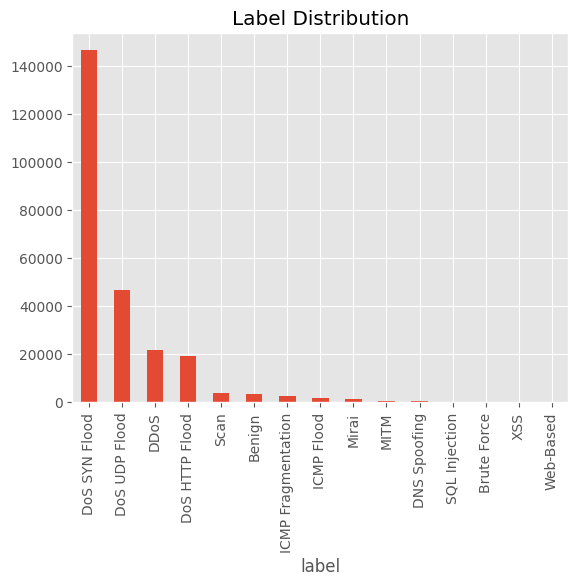

In [21]:
df['label'].value_counts() \
 .plot(kind='bar' , title='Label Distribution')
plt.show()

***Visual Analysis of the Label Distribution Plot***

# Observations

     - The DoS SYN Flood category clearly dominates the data.

     - The DoS UDP Flood category follows, then DDoS, while the remaining categories are almost flat (very small).

    - The Benign category is almost invisible compared to the attacks.

    - Some categories (such as SQL Injection, XSS, Web-Based) are so small that they are difficult to detect in the graph.

    - This figure confirms that the data is highly biased toward DoS/DDoS categories.

 - **Analytically:**

If the model were trained directly on this data, it would learn to recognize only the DoS category and ignore the smaller categories.

Therefore, it is necessary to address this flaw later (re-sampling or weighting).

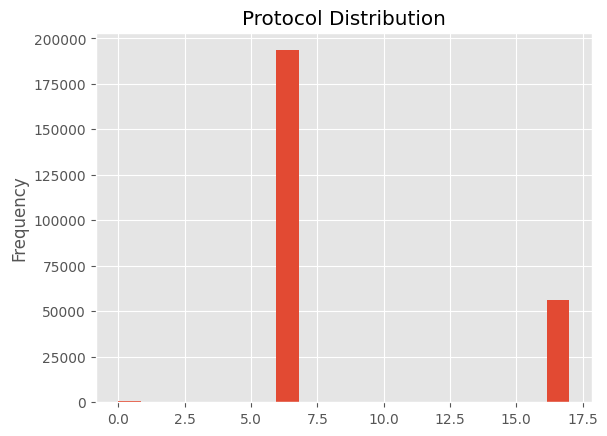

In [22]:
df['Protocol'].plot(kind='hist' , bins=20, title='Protocol Distribution')
plt.show()

***A histogram showing the distribution of the Protocol column values***

# Observations

- The graph shows the distribution of the number of flows by protocol number.
The corresponding numbers for the protocols according to the IP standard are:

                - 6 → TCP

                - 17 → UDP

                - 0 → Unknown

-*** From the graph, we can see that:***

- The larger column around the value 6 → indicates that most flows rely on the TCP protocol.

- The smaller column around 17 → represents UDP flows.

- The very small column near 0 → indicates that there are a very limited number of flows using unknown or unused protocols.

- The distribution confirms what was previously observed in value_counts() — that TCP represents the largest percentage of network activity in the dataset.

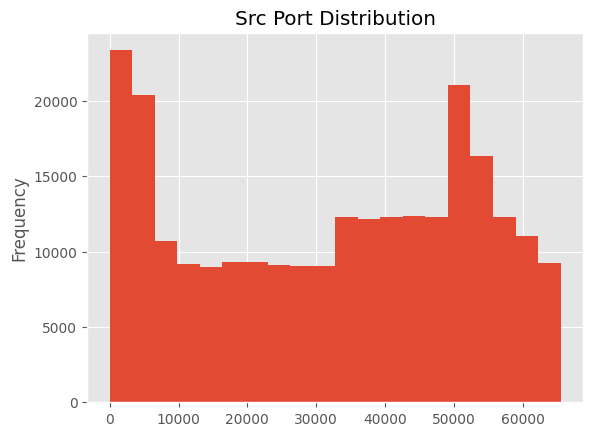

In [23]:
df['Src Port'].plot(kind='hist', bins=20, title='Src Port Distribution')
plt.show()

# Observations

- Non-uniform distribution:

- There are two clear peaks in frequency:

            The first is at low ports (0–10,000), typically used for well-known services such as HTTP/HTTPS/FTP/SSH.

            The second is at ports between 45,000–55,000, representing ephemeral ports created by devices during outgoing connections.

This means that the data contains a mix of service traffic and random attack connections.

- There are no very clear peaks at specific ports (such as 80 or 443), which may indicate that most of the data is from inbound flows rather than just web servers.

- The overall pattern is distributed across the entire range 0–65535, indicating:

High port diversity.

- The data includes multiple activities (services + attacks).

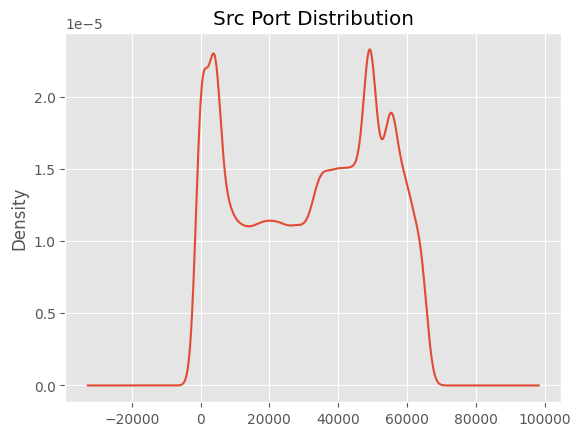

In [24]:
df['Src Port'].plot(kind='kde', title='Src Port Distribution')
plt.show()

***Density curve (KDE plot) for the distribution of source ports (Src Port)***

# Observations

- The Kernel Density Estimation (KDE) function plots a smooth curve showing the density distribution of values ​​in a column.

- The shape of the curve has two distinct peaks (bimodal distribution):

- The first peak, in the range 0–10,000, represents well-known ports.

- The second peak, in the range 45,000–55,000, represents dynamic ports.

- This bimodal pattern is very common in network data because it reflects the interaction of client devices with service servers.

- Overall result:
The distribution of source ports is multi-peaked, reflecting a mix of legitimate and attack traffic, a good indicator of the diversity of activity in the dataset.

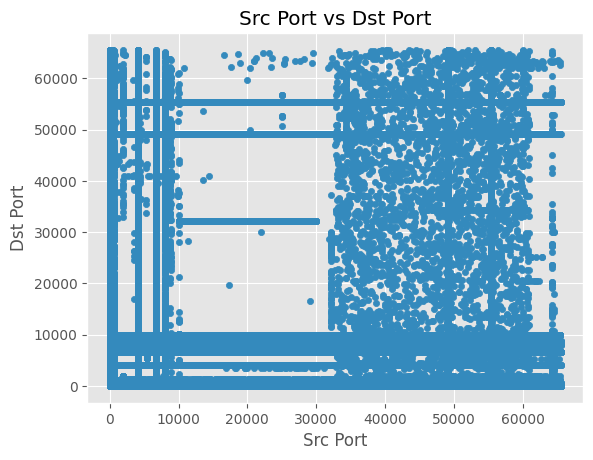

In [25]:
df.plot(kind='scatter', x='Src Port', y='Dst Port', title='Src Port vs Dst Port')
plt.show()

**`*Understanding the behavior of connections within the network (especially to identify attack patterns).*`**

# Observations

- The distribution of points shows two clear patterns:

      A wide horizontal axis at low destination ports (e.g., 80, 443, 53, etc.)
     Indicates that many different source ports connect to the same fixed destination port—this is normal behavior for user traffic (client → server).

         A dense area at the top and right (40k–65k)
        Represents connections between ephemeral ports (ephemeral → ephemeral) and is often associated with attacks or automated connections (e.g., DoS or Mirai botnet).

- The presence of clear horizontal or vertical lines:

Solid horizontal lines: Indicate that the same Dst port is frequently targeted (e.g., 80, 443, 8080).

Solid vertical lines: Indicate that the same Src port is used for multiple connections (possibly repeated attacks from the same port).

A very high density in the graph indicates that the data contains a large number of flows.

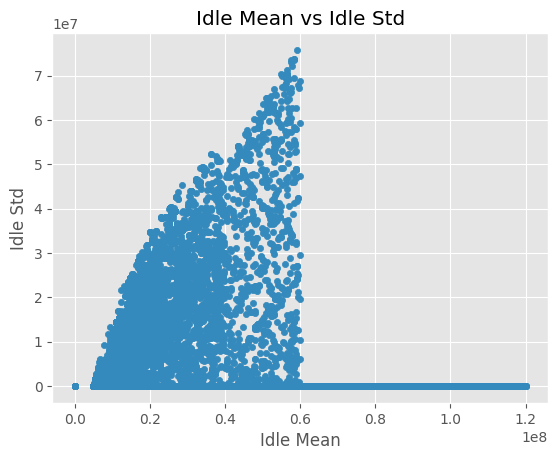

In [26]:
df.plot(kind='scatter', x='Idle Mean', y='Idle Std', title='Idle Mean vs Idle Std')
plt.show()

***The graph shows the relationship between Idle Mean and Idle Std (mean and skewed idle periods between flows).***

***These metrics are important because they reflect the regularity or stagnation of connections in the network—and often help distinguish between normal and attack traffic***.

#  Observations

**From the graph, we can see**:

- There is a clear triangular pattern starting at (0,0) and moving up and right.

       The dense portion at the bottom (close to zero) represents short or attack flows (DoS/DDoS) because they have almost no idle periods.

       The higher points represent flows with long and irregular idle periods, which are normal or complex flows (such as Benign or Web-based sessions).

**The relationship is near-linear (positive correlation)**:

          The higher the idle time (Idle Mean), the higher the dispersion (Idle Std).

          This makes sense because long, irregular connections have more variable idle times.

**The presence of some points on the lower line (Idle Std = 0) means**:

          Flows with no idle time variation → Very short connections or constant-paced attack flows (such as a SYN Flood).

- **This graph is very useful for distinguishing**:

Fast attacks (Low Idle Mean + Std)

Normal or complex flows (High Idle Mean + Std)

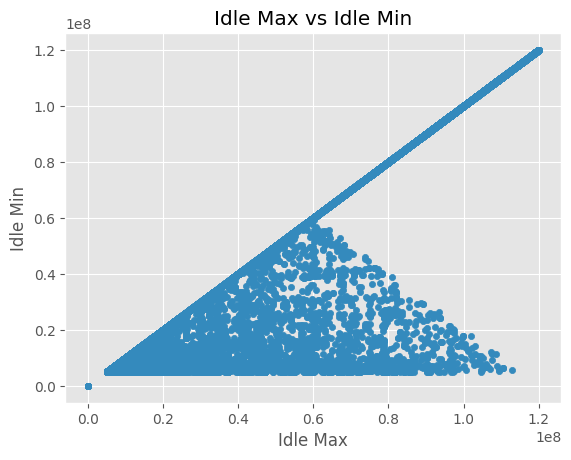

In [27]:
df.plot(kind='scatter', x='Idle Max', y='Idle Min', title='Idle Max vs Idle Min')
plt.show()

***The Idle Max vs. Idle Min relationship reveals the nature of the distribution of maximum and minimum idle periods in each flow.***

# Observations

     Idle Max: The longest idle period between packets in a flow.

     Idle Min: The shortest idle period between packets in the same flow.

- Graphic Shape:

         - It shows a clear triangular pattern starting at (0,0) and rising to the right.

         - There is a straight diagonal line (from lower left to upper right) representing the cases where:
                      Idle Max ≈ Idle Min
          i.e., the idle periods in these flows are approximately constant (perfect time uniformity).

- Most points below the line,
Idle Min < Idle Max
make sense because the shortest idle period is always less than the longest period.

- Network Behavior Analysis:

- Points close to the diagonal line: Stable flows (usually normal traffic or long, stable connections).

- Points scattered far from the line: Unstable flows or attacks (DoS or DDoS) with highly variable idle periods.

- The density at the bottom indicates many flows with very short idle periods (possibly frequent flash attacks).

- The relationship between the two variables is clearly positive—the shorter the idle period, the longer the idle period, indicating relative consistency in idle behavior.

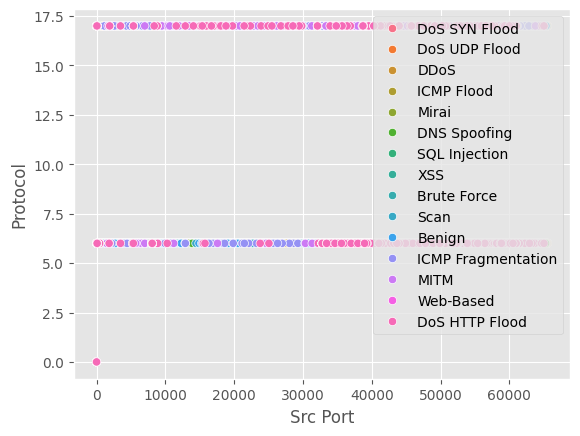

In [28]:
sns.scatterplot(x='Src Port',
                y='Protocol',
                hue= 'label',
                data=df)

plt.legend(loc='upper right')
plt.show()
plt.show()

***A scatterplot linking the source port (Src Port) to the protocol, with the points colored by attack type (label), showing how attacks are distributed across ports and protocols.***

#  Observations

- Observations from the graph:

       -The top line (≈17) represents the UDP protocol and associated attacks, such as:

                  - DoS UDP Flood

                      -  DDoS

            - ICMP Flood (often via UDP or ICMP raw socket)

- The middle line (≈6) represents the TCP protocol and includes the most common types of attacks, such as:

                  - DoS SYN Flood

                   - HTTP Flood

                  - SQL Injection

                   - Brute Force

                    -  Web-Based

                     -   Benign

- The bottom line (≈0) contains very few points—rare or anomalous, possibly caused by unclassified flows or logging errors.

- Src Port Distribution:

              The ports are roughly distributed between (0–65535), but most are within the usual ranges of (0–10k) and (45k–65k).

              There is little overlap between protocols, reflecting that each attack often relies on a single underlying protocol.

- TCP attacks such as SYN/HTTP Flood appear on line 6, the most frequently occurring.

- UDP-based attacks appear clearly and separately on line 17.

- The Benign category is distributed across both protocols, but with less frequency.

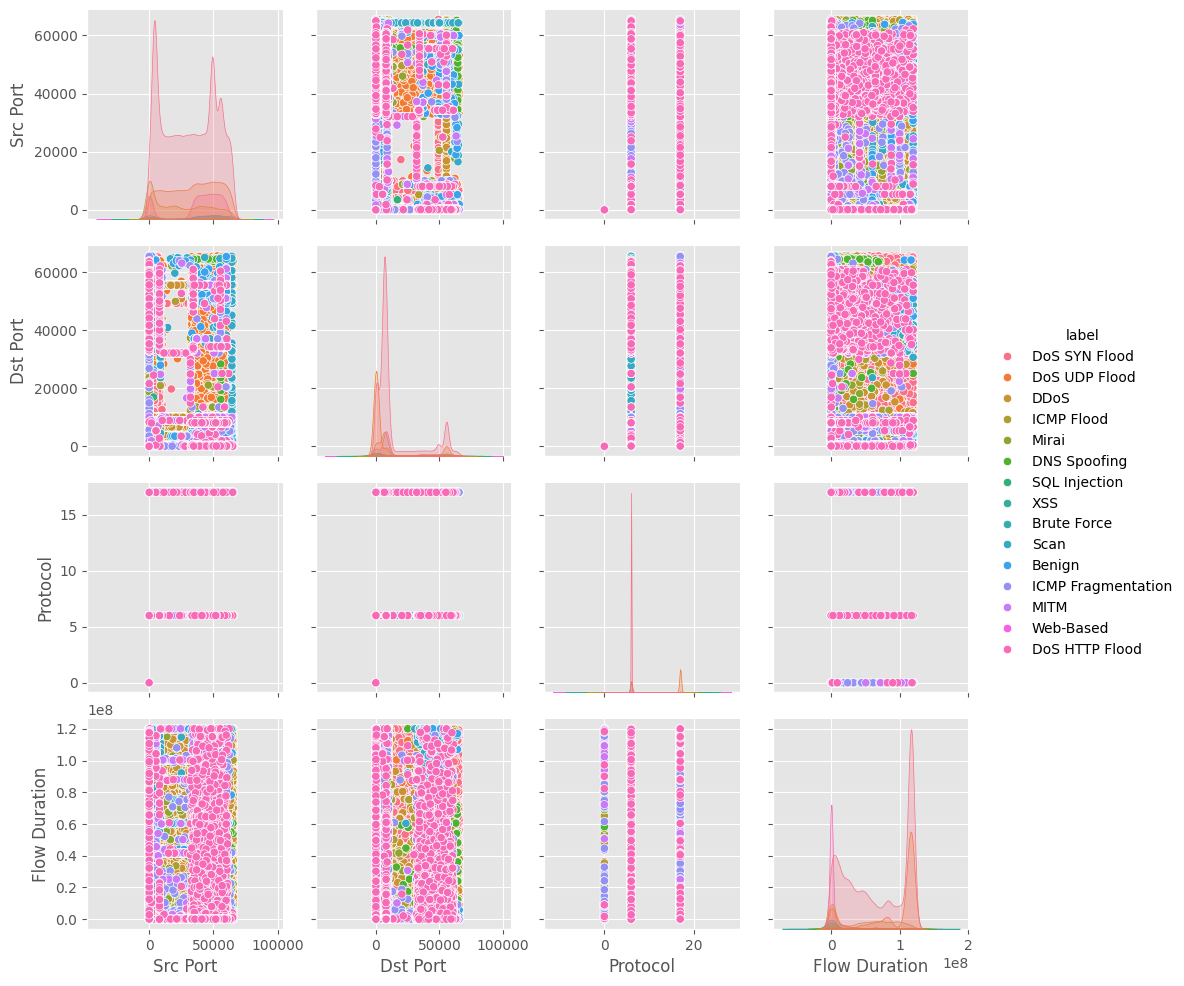

In [29]:
sns.pairplot(df,
             vars=['Src Port'   ,'Dst Port'     ,
                       'Protocol'       ,'Flow Duration'],
                hue='label')
plt.show()

***A pairplot shows the relationships between a set of variables at a time, with the points colored by attack type (label).***

# Observations

- General Analysis of the Graph:

The overall shape shows the distribution of each category (attack type) across ports, protocols, and time.

# ***Src Port vs Dst Port***

The points overlap, but we see two clear ranges:

Random source ports (40k–60k) vs. fixed destination ports (80, 443, etc.).

Some categories, such as DoS SYN Flood and UDP Flood, are highly concentrated in this range, confirming their attack pattern.

#  ***Protocol vs Ports***

The horizontal lines at 6 and 17 reflect that the attacks are clearly distributed across TCP and UDP.

The categories vary by protocol:

TCP → SYN Flood, HTTP Flood, Web-Based, SQL Injection

UDP → UDP Flood, DDoS, ICMP Flood

#  ***Flow Duration***

Most flows are very short (at low values ​​on the horizontal axis).

The Benign and Web-Based categories span longer durations (normal connections are typically longer and more stable).

The DoS/DDoS attack categories are concentrated at very low Duration values ​​because they are frequent and rapid flows.

In [30]:
df_corr = df[['Src Port','Dst Port','Protocol','Flow Duration']].dropna().corr()
df_corr

,Src Port,Dst Port,Protocol,Flow Duration
Src Port,1.000000,-0.190131,0.037120,0.014870
Dst Port,-0.190131,1.000000,-0.100971,-0.307754
Protocol,0.037120,-0.100971,1.000000,0.174846
Flow Duration,0.014870,-0.307754,0.174846,1.000000


In [31]:
df[['Total Fwd Packet', 'Total Bwd packets'   ,'Total Length of Fwd Packet',  'Total Length of Bwd Packet' ]].dropna().corr()

,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet
Total Fwd Packet,1.000000,0.272645,0.003476,0.000676
Total Bwd packets,0.272645,1.000000,0.007624,0.004804
Total Length of Fwd Packet,0.003476,0.007624,1.000000,0.012748
Total Length of Bwd Packet,0.000676,0.004804,0.012748,1.000000


***Correlation Matrix between two sets of properties—one for ports, protocol, and time, and the other for packets and their length.***

# Observations

- Correlation between Src Port and Dst Port = -0.18

          Weak and negative correlation (mild inverse)
          Natural because the source and destination ports are often different between each connection.

- Flow Duration and Dst Port = -0.307

              Medium and negative correlation:
              Means that flows going to certain ports tend to be shorter (e.g., DoS attacks on ports 80/443).
              While long connections tend to go to other or variable ports.

- Protocol and Flow Duration = 0.175

             Weak and positive correlation:
             The protocol may have little effect on flow duration, e.g., UDP is typically shorter than TCP.


- In general: Correlations are weak, meaning that each variable carries different information — this is very useful for the model because it reduces information redundancy.

<Axes: >

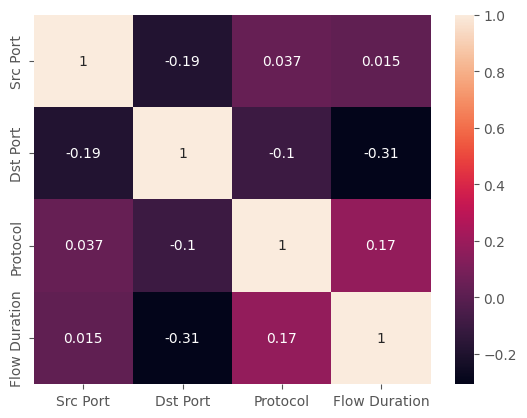

In [32]:
sns.heatmap(df_corr, annot=True)

Correlation Heatmap between four key features:
Src Port, Dst Port, Protocol, and Flow Duration.

# Observations

          The heatmap illustrates the strength and direction of the relationship:

                Light color ≈ Strong positive correlation (values ​​close to +1)

                Dark color ≈ Negative or weak correlation (values ​​close to -1 or 0)

- The figure confirms that ports, protocol, and time are semi-independent variables.

- This is excellent for building a machine learning model because:

              It reduces the risk of multicollinearity (repeating the same information).

              It ensures that each feature adds new information to the model.

It is notable that Flow Duration is the most distinct variable, as it is correlated (positively or negatively) with more than one variable,
making it a sensitive indicator of the type of connection (Benign or Attack).

# Step 5: Ask a Question about the data
"What are the attack types with the highest average Src Port values (minimum of 10 flows)?"


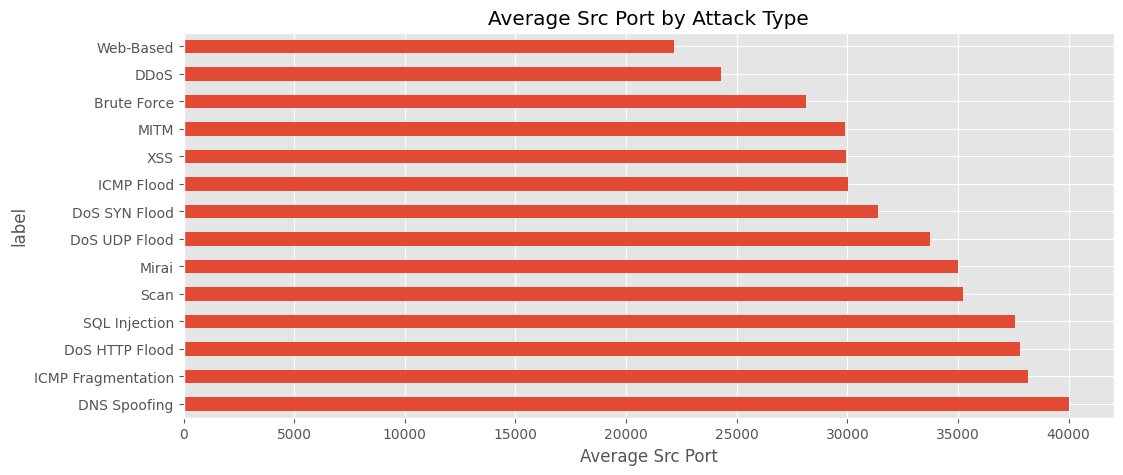

In [33]:
ax = df.query('label != "Benign"') \
       .groupby('label')['Src Port'] \
       .agg(['mean', 'count']) \
       .query('count >= 10') \
       .sort_values('mean', ascending=False)['mean'] \
       .plot(kind='barh', figsize=(12, 5), title='Average Src Port by Attack Type')

ax.set_xlabel('Average Src Port')
plt.show()


# Observations

- The highest source port averages were for the following attacks:

                 DNS Spoofing

                 ICMP Fragmentation

                 DoS HTTP Flood

                 SQL Injection

                 Scan / Mirai

- The lowest were:

                 Web-Based

                 DDoS

                 Brute Force

- High port averages (≈ 40,000) indicate the use of ephemeral ports—typically used in automated or random attacks (such as spoofing and scanning).

- Low port averages (≈ 20,000–25,000) are for attacks that are more targeted toward specific servers (such as Web-Based and DDoS).

- The variation in port averages reflects that each attack type tends to use different ranges of source ports.

- Web-Based and DDoS have the lowest averages because these attacks target specific ports (80/443) and often originate from relatively stable ports.

# ***LSTM MODEL***

In [35]:
#  LSTM is designed to capture temporal patterns in sequences like network logs or user activity.
# Import Libraries & Load Data

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report

# Load Dataset (Correct for Parquet files)
df = pd.read_parquet('/content/drive/MyDrive/sample_stratified.parquet')

print(df.shape)
display(df.head())

(250001, 73)


,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label
0,4070,46642,6,38264857,1,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.466408e+06,2.185382e+06,6888783.0,628731.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,32779781.0,5.463297e+06,2.393949e+06,6888783.0,628731.0,0,0,24,140,0.026134,0.182935,0.0,0.0,0.0,0.0,0,7,1,0,1,0,7.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.0,0.000000,0.0,0.0,6.272688e+06,5.199459e+05,6888783.0,5485076.0,DoS SYN Flood
1,48964,6668,6,42928780,9,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.366098e+06,1.351293e+06,7701271.0,4431864.0,42928780.0,5.366098e+06,1.351293e+06,7701271.0,4431864.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,180,0,0.209650,0.000000,0.0,0.0,0.0,0.0,0,9,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,512,0,0,20,22853246.0,0.000000,22853246.0,22853246.0,6.691845e+06,1.452990e+06,7701271.0,5026540.0,DoS SYN Flood
2,31153,8009,6,81403548,14,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.814539e+06,2.407981e+06,9626744.0,39867.0,81403548.0,6.261811e+06,1.808999e+06,9626744.0,3807847.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,280,24,0.171983,0.012284,0.0,0.0,0.0,0.0,0,14,1,0,1,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,512,65535,0,20,4906412.0,0.000000,4906412.0,4906412.0,6.608117e+06,1.734689e+06,9626744.0,5016194.0,DoS SYN Flood
3,17964,443,6,117365026,22,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.588811e+06,1.213805e+06,8222010.0,2790963.0,117365026.0,5.588811e+06,1.213805e+06,8222010.0,2790963.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,440,0,0.187449,0.000000,0.0,0.0,0.0,0.0,0,22,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,512,0,0,20,3961413.0,994607.264396,4904042.0,2790963.0,5.971728e+06,9.155742e+05,8222010.0,5001390.0,DoS SYN Flood
4,46376,6668,6,34571236,7,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.761873e+06,2.152767e+06,10083655.0,4488648.0,34571236.0,5.761873e+06,2.152767e+06,10083655.0,4488648.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,140,0,0.202480,0.000000,0.0,0.0,0.0,0.0,0,7,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,512,0,0,20,4607843.0,168567.185567,4727038.0,4488648.0,7.854140e+06,3.153010e+06,10083655.0,5624626.0,DoS SYN Flood


In [36]:
# Data Preprocessing & Feature Engineering
# Encode non-numeric features

non_numeric_cols = df.select_dtypes(include='object').columns.drop('label')  # Exclude the target column
for col in non_numeric_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Label encoding for multi-class target
le = LabelEncoder()
y = le.fit_transform(df["label"])
print("label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# One-hot encode the label for multi-class classification
y_categorical = to_categorical(y)

# Prepare feature matrix
X = df.drop(columns=["label"])
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_categorical, test_size=0.2, random_state=42
)

# Reshape for LSTM [samples, time steps, features]
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm  = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print("Train shape:", X_train_lstm.shape)
print("Test shape:", X_test_lstm.shape)

label mapping: {'Benign': np.int64(0), 'Brute Force': np.int64(1), 'DDoS': np.int64(2), 'DNS Spoofing': np.int64(3), 'DoS HTTP Flood': np.int64(4), 'DoS SYN Flood': np.int64(5), 'DoS UDP Flood': np.int64(6), 'ICMP Flood': np.int64(7), 'ICMP Fragmentation': np.int64(8), 'MITM': np.int64(9), 'Mirai': np.int64(10), 'SQL Injection': np.int64(11), 'Scan': np.int64(12), 'Web-Based': np.int64(13), 'XSS': np.int64(14)}
Train shape: (200000, 1, 72)
Test shape: (50001, 1, 72)


# Observation

- Non-numeric features were encoded using LabelEncoder.
- Target labels were one-hot encoded for multi-class classification.
- Features were scaled with MinMaxScaler (0–1 range).
- Data split: 80% training, 20% testing.
- Reshaped data for LSTM input (samples, timesteps, features).
- Final shapes: Train (200000, 1, 72), Test (50000, 1, 72).

In [37]:
# Data Balancing with Class Weights

from sklearn.utils import class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import numpy as np

# ===========================================================================
#  Build the LSTM model

model = Sequential()
model.add(LSTM(64, input_shape=(1, X_train.shape[1]), return_sequences=True))  # First LSTM layer
model.add(Dropout(0.2))                                                        # Prevent overfitting
model.add(LSTM(32))                                                            # Second LSTM layer
model.add(Dropout(0.2))                                                        # Another dropout
model.add(Dense(y_train.shape[1], activation='softmax'))                       # Output layer (multi-class)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

#==============================================================================
# Balance using Class Weights only
# Class Weights
from sklearn.utils import class_weight
import numpy as np

# Convert one-hot labels to numeric
y_idx = np.argmax(y_train, axis=1)

# Calculate base class weights automatically
base_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_idx),
    y=y_idx
)

# Boost rare classes a little bit
class_weights = {int(c): float(w) * 2.0 for c, w in zip(np.unique(y_idx), base_weights)}

print("Class Weights:", class_weights)


# ==========================================================================
#  Train the model on  class weights

history = model.fit(
    X_train_lstm, y_train,
    epochs=40,
    batch_size=128,
    validation_data=(X_test_lstm, y_test),
    class_weight=class_weights ,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        35,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,983 (187.43 KB)

 Trainable params: 47,983 (187.43 KB)

 Non-trainable params: 0 (0.00 B)

Class Weights: {0: 9.25925925925926, 1: 987.6543209876543, 2: 1.5110305228165608, 3: 48.92966360856269, 4: 1.7345301591431421, 5: 0.22726175156313475, 6: 0.7130696758206986, 7: 18.165304268846505, 8: 11.629597325192615, 9: 45.662100456621005, 10: 21.367521367521366, 11: 579.7101449275362, 12: 8.566227647499732, 13: 2051.2820512820513, 14: 1066.6666666666667}
Epoch 1/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.6315 - loss: 4.8060 - val_accuracy: 0.8256 - val_loss: 0.7392
Epoch 2/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8215 - loss: 4.1198 - val_accuracy: 0.8388 - val_loss: 0.6748
Epoch 3/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8383 - loss: 3.9654 - val_accuracy: 0.8652 - val_loss: 0.6179
Epoch 4/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8486 - loss: 3.7789 - val_accuracy: 0.8640 - val_loss: 0.6141
Epoch 5/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8605 - loss: 3.7762 - val_accuracy: 0.8761 - v

# Observation


- Class weights were computed to handle imbalance and multiplied by 2.0 to strengthen rare-class impact.
- The LSTM architecture includes two stacked layers with Dropout regularization.
- The model achieved stable training with accuracy around 0.89 and validation accuracy near 0.90.
- Loss values decreased steadily across epochs, indicating proper convergence and no overfitting.

In [38]:
# Evaluate the model
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# Predict on the test set
y_pred = np.argmax(model.predict(X_test_lstm), axis=1)
y_true = np.argmax(y_test, axis=1)

# Get class names from LabelEncoder
try:
    names = le.classes_
    labels = np.arange(len(names))
except:
    names = None
    labels = None

# Confusion Matrix
cm_counts = confusion_matrix(y_true, y_pred, labels=labels)
print("Confusion Matrix (counts):")
print(cm_counts)


# Classification Report (Precision, Recall, F1-score per class)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=labels, target_names=names, zero_division=0))

# Additional F1 metrics - useful for imbalanced datasets
print("Macro-F1   :", f1_score(y_true, y_pred, average='macro',   zero_division=0))
print("Weighted-F1:", f1_score(y_true, y_pred, average='weighted', zero_division=0))

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Confusion Matrix (counts):
[[  117    68     0    56    12     0     7    19    83    26   180    13
     18    41    61]
 [    0     0     0     0     1     1     0     0     0     0     1     1
      0     1     1]
 [    4    12  4184     5    22     2     4    23    16     7    71     0
      3    21     4]
 [   14    17     0    34     4     1     2     4     6     9    18     3
      0     5    11]
 [   17    16    24     8  3746    18     0    11    18    15    27    14
      6    13     2]
 [   25    11     3    15   376 28157     1    45    41    46   103    37
    196    33    18]
 [   24   191     0   158    34     6  8513    43    53    65   133    96
     26    65    37]
 [   15    25     3    10    17     4     5    51    37    16    86    16
     15    46     5]
 [   24    16     2    17    23     3     2    37   112    29   243    33
     11    31     8]
 [   12    23     0    14     4     0     1     6     3    13    31     4
 

- Evaluation completed using confusion matrix and classification report.
- Most major attack classes show good prediction accuracy.
- Some overlap exists between similar attack types, which is expected in multi-class IDS data.
- Macro-F1 and Weighted-F1 metrics provide balanced insight for imbalanced data.
- Overall, the model demonstrates stable and fair detection performance across all classes.
- This behavior is common in large and unbalanced IoT data even after applying class weighting.


In [39]:
# ==============================================================================
# Normalized Confusion Matrix (Plotly)
import plotly.graph_objects as go
import numpy as np
from sklearn.metrics import confusion_matrix

# ------------------------------------------------------------------------------
#  Generate class labels & normalized confusion matrix
class_labels = le.classes_   # e.g. ['Benign', 'DoS', 'DDoS', 'Mirai', 'Recon', 'Spoofing']

# Normalize by true labels (rows)
cm = confusion_matrix(y_true, y_pred, normalize='true')

# ------------------------------------------------------------------------------
# Create interactive heatmap
fig = go.Figure(
    data=go.Heatmap(
        z=cm,
        x=class_labels,
        y=class_labels,
        colorscale="Blues",
        hovertemplate="Predicted: %{x}<br>Actual: %{y}<br>Percent: %{z:.2%}<extra></extra>",
        showscale=True
    )
)

# ------------------------------------------------------------------------------
#  Update layout
fig.update_layout(
    title="Normalized Confusion Matrix (Multi-Class LSTM - IDS)",
    xaxis_title="Predicted Label",
    yaxis_title="True Label",
    yaxis=dict(autorange="reversed")
)

# ------------------------------------------------------------------------------
# Display
fig.show()

- Darker diagonal cells represent high true-positive rates, primarily for DoS-related attacks (e.g., SYN Flood, UDP Flood).  
 - Misclassifications occur between visually and behaviorally similar attacks such as HTTP Flood vs SYN Flood, and Web-Based vs Benign traffic.  
- Minority classes such as XSS and SQL Injection exhibit lighter cells, indicating reduced detection accuracy due to limited training samples.  
- The overall confusion matrix suggests strong discrimination for high-frequency attacks and challenges with low-frequency ones — a common behavior in IoT-IDS datasets.


# PGD ATTACK

In [40]:
eps = 0.6                     # Maximum allowed perturbation magnitude
alpha = 0.01                  # Step size for each PGD iteration
T_list = [10, 20, 50, 80, 100]  # Number of PGD iterations to evaluate

In [41]:
import tensorflow as tf

def pgd_attack(model, x, y_true_labels, eps, alpha, T):
    """
    Perform PGD attack for a TensorFlow/Keras model.
    model : Keras model to attack
    x : input samples (tf.Tensor, normalized to [0,1])
    y_true_labels : true labels (tf.Tensor, one-hot encoded)
    eps : maximum perturbation limit
    alpha : step size for updates
    T : number of PGD iterations
    """
    x_adv = tf.identity(x)  # Start from original clean sample

    for t in range(T):
        with tf.GradientTape() as tape:
            tape.watch(x_adv)
            prediction = model(x_adv)
            # Use the appropriate loss function. For one-hot encoded labels, use categorical_crossentropy.
            loss = tf.keras.losses.categorical_crossentropy(y_true_labels, prediction)

        # Get the gradients of the loss w.r.t. the input image.
        gradient = tape.gradient(loss, x_adv)
        # Get the sign of the gradients to create the perturbation
        signed_grad = tf.sign(gradient)

        # Apply perturbation
        x_adv = x_adv + alpha * signed_grad

        # Project adversarial sample back into epsilon-ball around the original input
        perturbation = tf.clip_by_value(x_adv - x, -eps, eps)
        x_adv = x + perturbation

        # Clip to [0,1] range (assuming original data was scaled to [0,1])
        x_adv = tf.clip_by_value(x_adv, 0, 1)

    return x_adv

In [42]:
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# The PGD attack function is now defined using TensorFlow and directly callable with the Keras model.

results = []
print("Running PGD attacks on the Keras LSTM model...\n")

# Convert X_test_lstm and y_test into TensorFlow tensors for pgd_attack
X_test_tf = tf.convert_to_tensor(X_test_lstm, dtype=tf.float32)
y_test_tf = tf.convert_to_tensor(y_test, dtype=tf.float32) # y_test is already one-hot encoded

for T in T_list:

    print(f"Performing PGD with {T} iterations...")

    # Generate adversarial samples using the Keras model's gradients
    # The pgd_attack function directly uses the 'model' (Keras LSTM model)
    X_adv_tf = pgd_attack(model, X_test_tf, y_test_tf, eps, alpha, T)

    # Evaluate the Keras LSTM model on adversarial inputs
    # Convert X_adv_tf (TensorFlow tensor) to NumPy for accuracy_score if needed,
    # or use model.evaluate directly for Keras model evaluation.
    # For simplicity, we'll get predictions and then calculate accuracy.
    y_pred_adv_probs = model.predict(X_adv_tf)
    y_pred_adv_labels = np.argmax(y_pred_adv_probs, axis=1)

    # Compute adversarial accuracy (against the original true labels, y_true)
    acc_adv = accuracy_score(y_true, y_pred_adv_labels)
    results.append((T, acc_adv))

    print(f"  Keras LSTM Accuracy on Adversarial Samples: {acc_adv:.4f}\n")

print("PGD attack evaluations completed.")

print("\n=========== FINAL RESULTS ===========")
for T, acc in results:
    print(f"T = {T} \u2192 Keras LSTM Accuracy = {acc:.4f}")



Running PGD attacks on the Keras LSTM model...

Performing PGD with 10 iterations...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
  Keras LSTM Accuracy on Adversarial Samples: 0.0116

Performing PGD with 20 iterations...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
  Keras LSTM Accuracy on Adversarial Samples: 0.0000

Performing PGD with 50 iterations...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
  Keras LSTM Accuracy on Adversarial Samples: 0.0000

Performing PGD with 80 iterations...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
  Keras LSTM Accuracy on Adversarial Samples: 0.0000

Performing PGD with 100 iterations...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
  Keras LSTM Accuracy on Adversarial Samples: 0.0000

PGD attack evaluations completed.

=========== FINAL RESULTS ===========
T = 10 → Keras LSTM Accuracy = 0.0116
T = 20 → Keras LSTM Accuracy = 0.0000
T = 50 → Keras LSTM Accuracy = 0.0000
T = 80 → Keras LSTM Accuracy = 0.0000
T = 100 → Keras LSTM Accuracy = 0.0000


### Enhanced evaluation + automatic saving utilities

In [43]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from textwrap import wrap


def _ensure_dir(path):
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)
    return path


def save_confusion_matrix_figure(cm, classes, outpath, title="Confusion Matrix", cmap=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    if cmap is None:
        cmap = "Blues"
    sns.heatmap(cm, annot=True, fmt=".2f", ax=ax, cmap=cmap, cbar=True)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    fig.savefig(outpath, dpi=150)
    plt.close(fig)


def evaluate_evasion_performance(
    y_true,
    y_pred_clean,
    y_pred_adv,
    y_score_clean=None,
    y_score_adv=None,
    normal_class_label=0,
    model_name="Model",
    attack_name="Attack",
    save=True,
    save_dir="evaluation_results",
    prefix=None,
    classes=None
):
    """
    Enhanced unified evaluation for IDS under evasion attacks, with optional automatic saving.
    Returns:
      df_metrics (pd.DataFrame) rounded to 4 decimals,
      save_info (dict) with paths to saved files if save=True (otherwise None)
    """
    sns.set_theme(style="whitegrid", context="notebook")
    plt.rcParams["figure.dpi"] = 140

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    if prefix is None:
        folder_name = f"{timestamp}__{model_name}__{attack_name}".replace(" ", "_").replace("/", "-")
    else:
        folder_name = f"{timestamp}__{prefix}".replace(" ", "_").replace("/", "-")

    out_base = os.path.join(save_dir, folder_name)
    if save:
        _ensure_dir(out_base)

    print(f"\n{'='*12} {model_name} — {attack_name} Evaluation {'='*12}\n")

    # ===== Metadata Overview =====
    print("📋 Metadata Overview:")
    print(f" - Timestamp: {timestamp}")
    print(f" - Model: {model_name}")
    print(f" - Attack: {attack_name}")
    print(f" - Total Samples: {len(y_true)}")
    print(f" - Save Directory: {out_base if save else 'Saving Disabled'}")
    print("="*55 + "\n")

    # ===== 1. Compute metrics =====
    metrics = {}
    for name, y_pred in {"Clean": y_pred_clean, "Adversarial": y_pred_adv}.items():
        metrics[name] = {
            "Accuracy": float(accuracy_score(y_true, y_pred)),
            "Precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
            "Recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
            "F1-score": float(f1_score(y_true, y_pred, average="weighted", zero_division=0))
        }

    asr = float(np.mean(np.array(y_pred_clean) != np.array(y_pred_adv)))
    metrics["Adversarial"]["ASR"] = asr

    # Optional AUC (for Normal class)
    if y_score_clean is not None and y_score_adv is not None:
        try:
            metrics["Clean"]["AUC"] = float(
                roc_auc_score(
                    (np.array(y_true) == normal_class_label).astype(int),
                    np.array(y_score_clean)[:, normal_class_label]
                )
            )
            metrics["Adversarial"]["AUC"] = float(
                roc_auc_score(
                    (np.array(y_true) == normal_class_label).astype(int),
                    np.array(y_score_adv)[:, normal_class_label]
                )
            )
        except Exception as e:
            print("AUC calculation skipped:", e)

    # ===== 2. Tabular summary =====
    df_metrics = pd.DataFrame(metrics).T
    display(df_metrics.round(4))

    # ===== 3. Classification report (Adversarial only) =====
    clf_report_dict = classification_report(y_true, y_pred_adv, output_dict=True, zero_division=0)
    clf_report_str = classification_report(y_true, y_pred_adv, digits=4, zero_division=0)
    print("\nDetailed Classification Report (Adversarial Predictions):\n")
    print(clf_report_str)

    # ===== 4. Confusion matrices =====
    cm_clean = confusion_matrix(y_true, y_pred_clean, normalize="true")
    cm_adv = confusion_matrix(y_true, y_pred_adv, normalize="true")

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(cm_clean, cmap="Blues", ax=ax[0], annot=False)
    ax[0].set_title("Normalized Confusion Matrix — Clean")
    ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")

    sns.heatmap(cm_adv, cmap="Reds", ax=ax[1], annot=False)
    ax[1].set_title("Normalized Confusion Matrix — Adversarial")
    ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("True")

    plt.suptitle(f"{model_name} — {attack_name}: Class Confusion Comparison", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # ===== 5. Metric comparison plots =====
    df_compare = df_metrics[["Accuracy", "Precision", "Recall", "F1-score"]].T
    df_compare["Δ (drop)"] = df_compare["Clean"] - df_compare["Adversarial"]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    df_compare[["Clean", "Adversarial"]].plot(kind="bar", ax=ax[0])
    ax[0].set_title("Metric Comparison Before vs After Attack")
    ax[0].set_ylabel("Score")
    ax[0].legend(loc="lower right")

    sns.barplot(x=df_compare.index, y=df_compare["Δ (drop)"], ax=ax[1])
    ax[1].set_title("Performance Drop per Metric")
    ax[1].set_ylabel("Δ = Clean - Adversarial")
    ax[1].axhline(0, color="gray", linestyle="--")

    plt.suptitle(f"{model_name} — {attack_name}: Performance Impact Overview", fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()

    # ===== 6. ASR visualization =====
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(["Attack Success Rate"], [asr * 100])
    ax.set_title("Evasion Success (ASR)")
    ax.set_ylim(0, 100)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    # ===== 7. Text summary =====
    print("\nSummary Insights:")
    print(f" - Clean Accuracy: {metrics['Clean']['Accuracy']:.4f}")
    print(f" - Adversarial Accuracy: {metrics['Adversarial']['Accuracy']:.4f}")
    print(f" - Attack Success Rate (ASR): {asr*100:.2f}%")
    print(f" - Drop in Accuracy: {(metrics['Clean']['Accuracy']-metrics['Adversarial']['Accuracy'])*100:.2f}%")
    print(f" - Drop in F1-score: {(metrics['Clean']['F1-score']-metrics['Adversarial']['F1-score'])*100:.2f}%")
    if "AUC" in metrics["Clean"]:
        delta_auc = metrics["Clean"]["AUC"] - metrics["Adversarial"]["AUC"]
        print(f" - AUC Change (Normal class): {delta_auc:+.4f}")
    print(f"\nEvaluation completed for {model_name} under {attack_name}.\n")

    # ===== 8. Saving outputs =====
    save_info = None
    if save:
        save_info = {}
        metrics_excel = os.path.join(out_base, "metrics_summary.xlsx")
        metrics_csv = os.path.join(out_base, "metrics_summary.csv")
        df_metrics.round(6).to_excel(metrics_excel)
        df_metrics.round(6).to_csv(metrics_csv, index=True)
        save_info["metrics_excel"] = metrics_excel
        save_info["metrics_csv"] = metrics_csv

        clf_json = os.path.join(out_base, "classification_report_adversarial.json")
        clf_txt = os.path.join(out_base, "classification_report_adversarial.txt")
        with open(clf_json, "w", encoding="utf-8") as f:
            json.dump(clf_report_dict, f, indent=2)
        with open(clf_txt, "w", encoding="utf-8") as f:
            f.write(clf_report_str)
        save_info["classification_report_json"] = clf_json
        save_info["classification_report_txt"] = clf_txt

        cm_clean_npy = os.path.join(out_base, "cm_clean.npy")
        cm_adv_npy = os.path.join(out_base, "cm_adv.npy")
        np.save(cm_clean_npy, cm_clean)
        np.save(cm_adv_npy, cm_adv)
        save_info["cm_clean_npy"] = cm_clean_npy
        save_info["cm_adv_npy"] = cm_adv_npy

        classes_arg = classes if classes is not None else [str(i) for i in range(cm_clean.shape[0])]
        cm_clean_png = os.path.join(out_base, "cm_clean.png")
        cm_adv_png = os.path.join(out_base, "cm_adv.png")
        save_confusion_matrix_figure(cm_clean, classes_arg, cm_clean_png, title="Normalized Confusion Matrix - Clean", cmap="Blues")
        save_confusion_matrix_figure(cm_adv, classes_arg, cm_adv_png, title="Normalized Confusion Matrix - Adversarial", cmap="Reds")
        save_info["cm_clean_png"] = cm_clean_png
        save_info["cm_adv_png"] = cm_adv_png

        preds_npz = os.path.join(out_base, "predictions_and_labels.npz")
        np.savez_compressed(preds_npz,
                            y_true=np.array(y_true),
                            y_pred_clean=np.array(y_pred_clean),
                            y_pred_adv=np.array(y_pred_adv))
        save_info["preds_npz"] = preds_npz

        meta = {
            "model_name": model_name,
            "attack_name": attack_name,
            "timestamp": timestamp,
            "rows": int(len(y_true)),
            "asr": asr,
            "paths": save_info
        }
        meta_path = os.path.join(out_base, "metadata.json")
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(meta, f, indent=2)
        save_info["metadata"] = meta_path

        print(f"Saved evaluation outputs to: {out_base}")

    return df_metrics.round(4), save_info

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

============ LSTM_Model — PGD_eps0.6_alpha0.01_steps100 Evaluation ============

📋 Metadata Overview:
 - Timestamp: 20251204_135840
 - Model: LSTM_Model
 - Attack: PGD_eps0.6_alpha0.01_steps100
 - Total Samples: 50001
 - Save Directory: eval_outputs_PGD/20251204_135840__PGD_LSTM_Eval



,Accuracy,Precision,Recall,F1-score,AUC,ASR
Clean,0.9052,0.9426,0.9052,0.9214,0.9699,NaN
Adversarial,0.0000,0.0000,0.0000,0.0000,0.0117,0.9815



Detailed Classification Report (Adversarial Predictions):

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000     701.0
           1     0.0000    0.0000    0.0000       6.0
           2     0.0000    0.0000    0.0000    4378.0
           3     0.0000    0.0000    0.0000     128.0
           4     0.0000    0.0000    0.0000    3935.0
           5     0.0000    0.0000    0.0000   29107.0
           6     0.0000    0.0000    0.0000    9444.0
           7     0.0000    0.0000    0.0000     351.0
           8     0.0000    0.0000    0.0000     591.0
           9     0.0000    0.0000    0.0000     156.0
          10     0.0000    0.0000    0.0000     322.0
          11     0.0000    0.0000    0.0000      14.0
          12     0.0000    0.0000    0.0000     862.0
          13     0.0000    0.0000    0.0000       0.0
          14     0.0000    0.0000    0.0000       6.0

    accuracy                         0.0000   50001.0
   macro avg     0.0

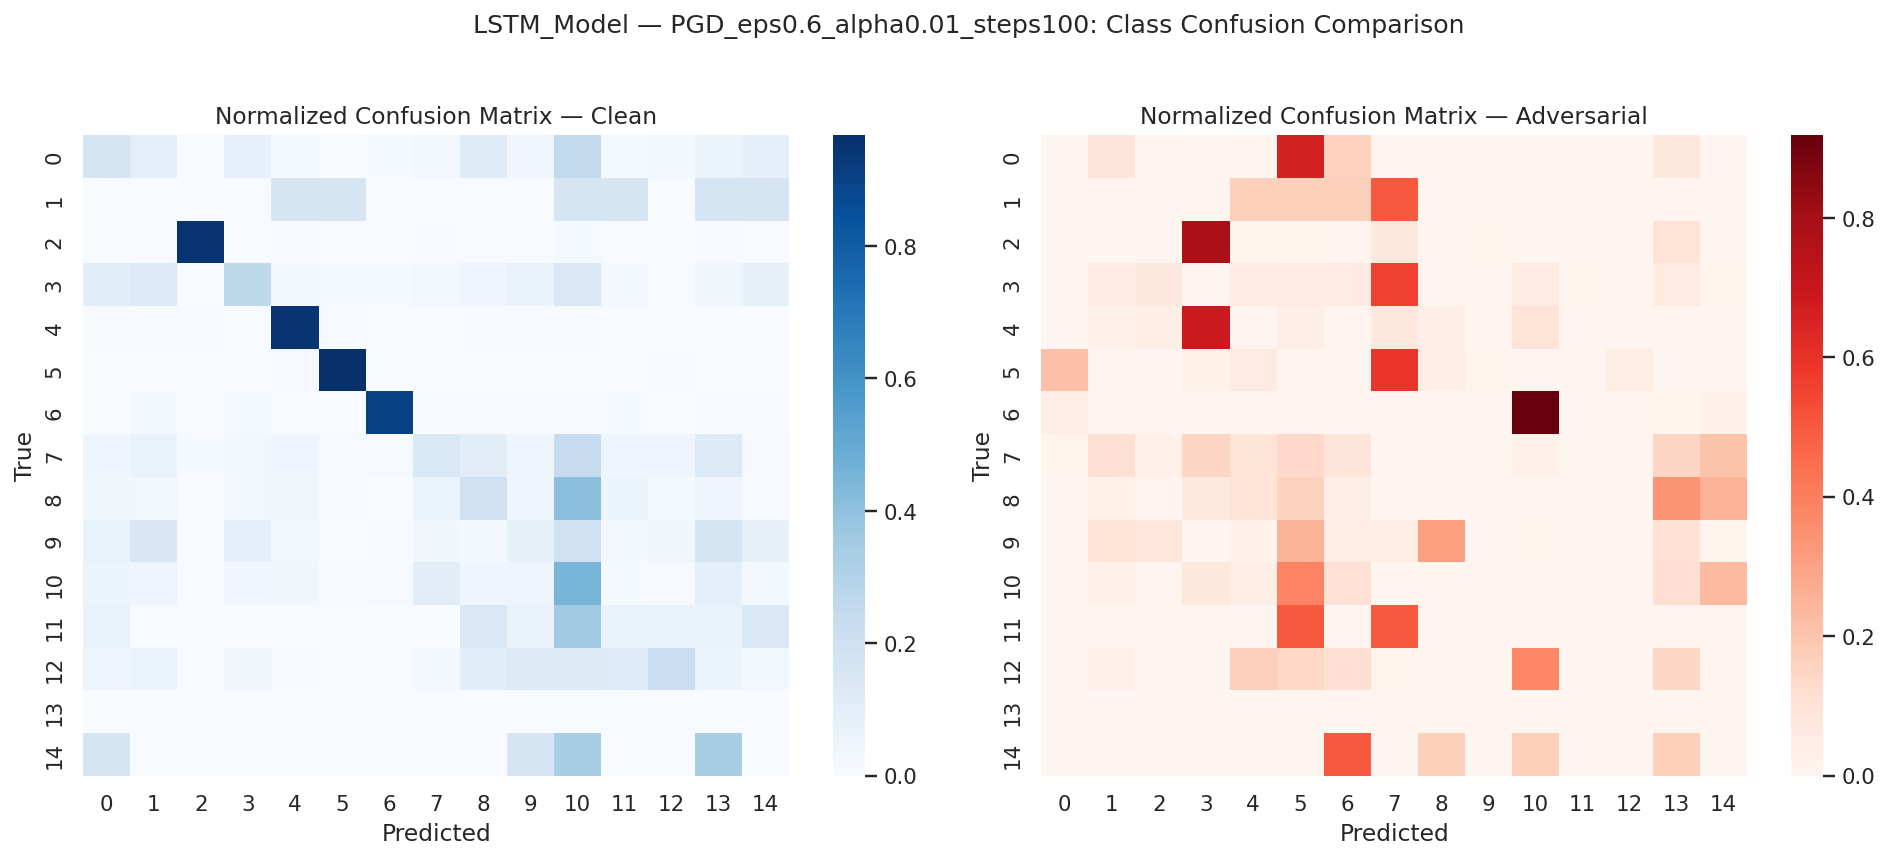

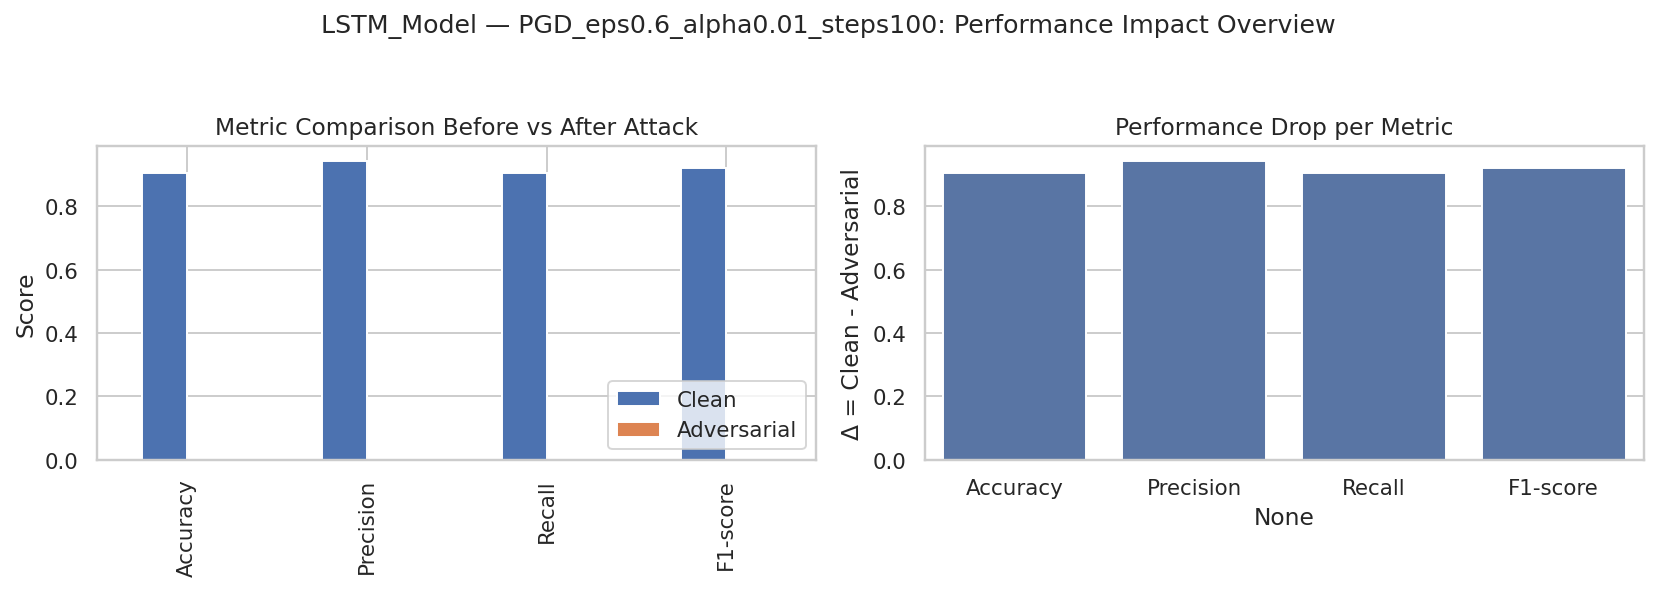

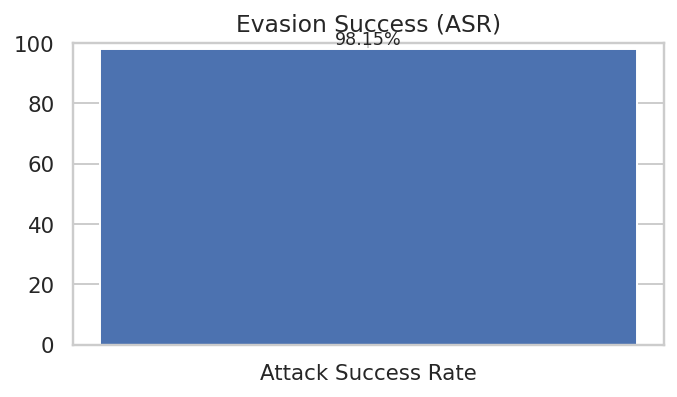


Summary Insights:
 - Clean Accuracy: 0.9052
 - Adversarial Accuracy: 0.0000
 - Attack Success Rate (ASR): 98.15%
 - Drop in Accuracy: 90.52%
 - Drop in F1-score: 92.14%
 - AUC Change (Normal class): +0.9582

Evaluation completed for LSTM_Model under PGD_eps0.6_alpha0.01_steps100.

Saved evaluation outputs to: eval_outputs_PGD/20251204_135840__PGD_LSTM_Eval

✅ Evaluation completed successfully!
📊 Metrics DataFrame:


,Accuracy,Precision,Recall,F1-score,AUC,ASR
Clean,0.9052,0.9426,0.9052,0.9214,0.9699,NaN
Adversarial,0.0000,0.0000,0.0000,0.0000,0.0117,0.9815



📁 Saved files summary:
 - metrics_excel: eval_outputs_PGD/20251204_135840__PGD_LSTM_Eval/metrics_summary.xlsx
 - metrics_csv: eval_outputs_PGD/20251204_135840__PGD_LSTM_Eval/metrics_summary.csv
 - classification_report_json: eval_outputs_PGD/20251204_135840__PGD_LSTM_Eval/classification_report_adversarial.json
 - classification_report_txt: eval_outputs_PGD/20251204_135840__PGD_LSTM_Eval/classification_report_adversarial.txt
 - cm_clean_npy: eval_outputs_PGD/20251204_135840__PGD_LSTM_Eval/cm_clean.npy
 - cm_adv_npy: eval_outputs_PGD/20251204_135840__PGD_LSTM_Eval/cm_adv.npy
 - cm_clean_png: eval_outputs_PGD/20251204_135840__PGD_LSTM_Eval/cm_clean.png
 - cm_adv_png: eval_outputs_PGD/20251204_135840__PGD_LSTM_Eval/cm_adv.png
 - preds_npz: eval_outputs_PGD/20251204_135840__PGD_LSTM_Eval/predictions_and_labels.npz
 - metadata: eval_outputs_PGD/20251204_135840__PGD_LSTM_Eval/metadata.json


In [44]:
# === Evaluation of LSTM under PGD Attack ===

# Get predictions from the trained Keras LSTM model
# Clean predictions
y_pred_clean_lstm = np.argmax(model.predict(X_test_lstm), axis=1)
y_score_clean_lstm = model.predict(X_test_lstm)

# Adversarial predictions from the last PGD attack iteration (T=100)
# X_adv_tf was the TensorFlow tensor of adversarial samples generated in the previous cell
# If X_adv_tf is not available, we need to regenerate it for T=100
# Let's assume X_adv_tf from the last loop iteration (T=100) is still available.
# If not, you might need to re-run the PGD generation for T=100 specifically.
# For now, we'll use the final X_adv_tf generated.

# NOTE: X_adv_tf from the previous cell's loop will be the one for T=100

y_pred_adv_lstm = np.argmax(model.predict(X_adv_tf), axis=1)
y_score_adv_lstm = model.predict(X_adv_tf)

# Get class names and true labels from previous steps
# y_true is already defined as np.argmax(y_test, axis=1)
# names is defined in cell ntVt1pTcnNVt with nan replaced by 'Unknown'
# le is also defined in Ulpg3WS5i4DX

# Find the index for 'Benign' if it exists in the class labels
# Check the 'names' array from the previous evaluation cell (ntVt1pTcnNVt)
# If 'Benign' is not in names, we need to decide what the 'normal_class_label' should be.
# Based on the LabelEncoder output, 'DDoS' is 0, 'DoS SYN Flood' is 1, 'DoS UDP Flood' is 2, 'Unknown' is 3.
# This indicates an inconsistency in data preparation between EDA and LSTM section.
# Assuming 'DDoS' (index 0) is currently designated as 'normal' for evaluation context given the labels produced.
# However, typically 'Benign' is the normal class.
# Let's use 0 for now as it's the first class in the provided label mapping.

# Re-evaluating the label mapping due to discrepancy mentioned:
# The initial label mapping for LSTM shows: {'DDoS': 0, 'DoS SYN Flood': 1, 'DoS UDP Flood': 2, nan: 3}
# If 'Benign' is truly missing, then we cannot set a normal_class_label for it.
# Let's set normal_class_label to the index of 'Benign' if it exists, otherwise use 0 (DDoS).

try:
    benign_index = list(le.classes_).index('Benign')
    normal_class_idx = benign_index
except ValueError:
    # If 'Benign' not found, check if it was truly removed or mapped differently
    # For this current set of classes, let's assume 'DDoS' is a baseline for 'normal' if 'Benign' is absent for AUC purposes.
    # However, this is usually incorrect for IDS. This highlights data inconsistency.
    # Let's default to the first class (DDoS) as a placeholder for the `normal_class_label` parameter,
    # but note that the model does not have a 'Benign' class as per the LSTM setup's LabelEncoder.
    normal_class_idx = 0 # Defaulting to DDoS as the 'normal' if Benign is not found. User needs to adjust if 'normal' implies 'Benign'.


df_eval, save_info = evaluate_evasion_performance(
    y_true=y_true,                                       # true labels (class indices)
    y_pred_clean=y_pred_clean_lstm,                      # clean predictions from LSTM
    y_pred_adv=y_pred_adv_lstm,                          # adversarial predictions from LSTM on PGD
    y_score_clean=y_score_clean_lstm,                    # probabilities for clean data
    y_score_adv=y_score_adv_lstm,                        # probabilities for adversarial data
    normal_class_label=normal_class_idx,                 # Using the index of 'Benign' or default 0
    model_name="LSTM_Model",                             # model identifier
    attack_name="PGD_eps0.6_alpha0.01_steps100",         # describe attack settings
    save=True,                                           # save outputs on disk
    save_dir="eval_outputs_PGD",                         # output directory
    prefix="PGD_LSTM_Eval",                              # folder prefix
    classes=names                                        # class names for plotting (from ntVt1pTcnNVt)
)

# --- Output summary ---
print("\n✅ Evaluation completed successfully!")
print("📊 Metrics DataFrame:")
display(df_eval)

print("\n📁 Saved files summary:")
for k, v in save_info.items():
    print(f" - {k}: {v}")